c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features 

                          Feature Set  Validation Accuracy
0                            Baseline             0.826087
1              Baseline + age_squared             0.826087
2  Baseline + age_squared + chol_high             0.831522
3           Baseline + all engineered             0.831522


c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features 

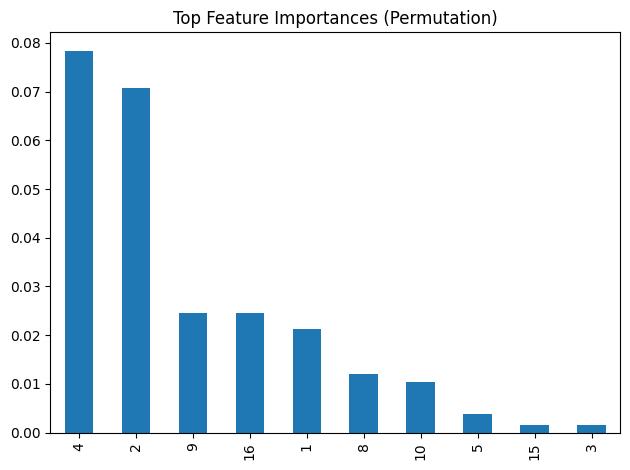

In [4]:
# Week 5 – Part B: Feature Engineering & Ablation (FINAL BULLETPROOF)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

# --------------------------------------------------
# Load & clean dataset
# --------------------------------------------------
df = pd.read_csv("../data/heart.csv")
df = df.replace("?", np.nan)

for col in ["ca", "thal"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Binary target
df["target"] = (df["num"] > 0).astype(int)

# --------------------------------------------------
# Feature Engineering (ALL NUMERIC)
# --------------------------------------------------
df["age_squared"] = df["age"] ** 2
df["chol_high"] = (df["chol"] > 240).astype(int)
df["exercise_risk"] = df["exang"] * df["oldpeak"]
df["heart_stress"] = df["trestbps"] * df["thalch"]

# --------------------------------------------------
# Feature sets for ablation
# --------------------------------------------------
baseline_cols = ["age", "sex", "cp", "trestbps", "chol", "fbs",
                 "restecg", "thalch", "exang", "oldpeak",
                 "slope", "ca", "thal"]

feature_sets = {
    "Baseline": baseline_cols,
    "Baseline + age_squared": baseline_cols + ["age_squared"],
    "Baseline + age_squared + chol_high": baseline_cols + ["age_squared", "chol_high"],
    "Baseline + all engineered": baseline_cols + ["age_squared", "chol_high", "exercise_risk", "heart_stress"]
}

y = df["target"]
results = []

# --------------------------------------------------
# Ablation experiment
# --------------------------------------------------
for name, cols in feature_sets.items():

    X = df[cols]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    categorical_cols = X.select_dtypes(include="object").columns.tolist()
    numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ])

    model = Pipeline([
        ("preprocess", preprocessor),
        ("logreg", LogisticRegression(max_iter=2000, solver="liblinear"))
    ])

    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    results.append((name, acc))

# --------------------------------------------------
# Ablation results
# --------------------------------------------------
ablation_df = pd.DataFrame(results, columns=["Feature Set", "Validation Accuracy"])
print(ablation_df)

# --------------------------------------------------
# Feature importance (final model)
# --------------------------------------------------
final_cols = feature_sets["Baseline + all engineered"]
X_final = df[final_cols]

X_train, X_val, y_train, y_val = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

categorical_cols = X_final.select_dtypes(include="object").columns.tolist()
numeric_cols = X_final.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

final_model = Pipeline([
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(max_iter=2000, solver="liblinear"))
])

final_model.fit(X_train, y_train)

r = permutation_importance(
    final_model, X_val, y_val,
    n_repeats=10, random_state=RANDOM_STATE
)

pd.Series(r.importances_mean).sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Feature Importances (Permutation)")
plt.tight_layout()
plt.savefig("../plots/feature_importance.png")
plt.show()
